ATIVIDADE DE PREPARAÇÃO DE DADOS

1. **Instalação de bibliotecas**

Utilizaremos as quatro bilbiotecas amis utilizadas para limpeza de dados:
- Pandas: usado para analisar e manipular dados em tabelas, como aqueles que você encontra em planilhas ou bancos de dados. Ele facilita a exploração, limpeza e processamento de dados e suas tabelas recebem o nome de DataFrame.
- Matplotlib: O Matplotlib é como uma caixa de ferramentas que permite transformar esses números em gráficos compreensíveis.
- Seaborn: Essa biblioteca permite a criação de gráficos estatísticos, tornando a visualização de dados intuitiva.
- Numpy:  uma biblioteca de código aberto destinada a realizar operações em arrays multidimensionais.

In [1]:
import pandas as pd #para ler, visualizar e printar infos do df
import matplotlib.pyplot as plt #para construir e customizar gráficos
import seaborn as sns #para visualizar uns gráficos
import numpy as np #numpy porque é sempre bom importar numpy né

**Lendo e visualizando o DataFrame**
- Leitura do arquivo no formato .csv, uma maneira econômica de guardar dados em tabelas. A biblioteca pandas possui uma função específica para ler esse tipo de arquivo e transformá-lo em um DataFrame, chamada .read_csv().

In [2]:
## Habilitar Google Drive no Colab
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/spotify1.csv', index_col=0) #Aqui estamos definindo que o arquivo ficará guardado no nome "df"
df.sort_values('song_popularity', ascending=False, inplace=True) #Deixa as músicas em ordem de popularidade
df.head(15) #aqui definimos que as primeiras 15 linhas aparecerão (lembrando que começa do 0)


,song_name,song_popularity,song_duration_ms,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,audio_mode,speechiness,tempo,time_signature,audio_valence
1757,Party In The U.S.A.,nao_sei,0.8220000000000001kg,0.519mol/L,0.36,0.0,10,0.177,-8.575,0,0.105,97.42,4,0.7,NaN
7574,I Love It (& Lil Pump),99,127946,0.0114kg,0.901mol/L,0.522,0.0,2.000,0.259,-8.304,1,0.33,104.053,4,0.329
11777,I Love It (& Lil Pump),99,127946,0.0114kg,0.901mol/L,0.522,0.0,2.000,0.259,-8.304,1,0.33,104.053,4,0.329
4301,I Love It (& Lil Pump),99,127946,0.0114kg,0.901mol/L,0.522,0.0,2.000,0.259,-8.304,1,0.33,104.053,4,0.329
14444,I Love It (& Lil Pump),99,127946,0.0114kg,0.901mol/L,0.522,0.0,2.000,0.259,-8.304,1,0.33,104.053,4,0.329
1229,I Love It (& Lil Pump),99,127946,0.0114kg,0.901mol/L,0.522,0.0,2.000,0.259,-8.304,1,0.33,104.053,4,0.329
3443,I Love It (& Lil Pump),99,127946,0.0114kg,0.901mol/L,0.522,0.0,2.000,0.259,-8.304,1,0.33,104.053,4,0.329
7465,I Love It (& Lil Pump),99,127946,0.0114kg,0.901mol/L,0.522,0.0,2.000,0.259,-8.304,1,0.33,104.053,4,0.329
9013,I Love It (& Lil Pump),99,127946,0.0114kg,0.901mol/L,0.522,0.0,2.000,0.259,-8.304,1,0.33,104.053,4,0.329
5608,I Love It (& Lil Pump),99,127946,0.0114kg,0.901mol/L,0.522,0.0,2.000,0.259,-8.304,1,0.33,104.053,4,0.329


2. **Analisando informações gerais do dataframe**

In [4]:
df.head() #para visualizar o começo do seu dataframe
df.info() #para obter informações do seu dataframe
df.describe() #para ver um descrição estatística mais detalhada

<class 'pandas.core.frame.DataFrame'>
Index: 18835 entries, 1757 to 9956
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   song_name         18835 non-null  object 
 1   song_popularity   18835 non-null  object 
 2   song_duration_ms  18835 non-null  object 
 3   acousticness      18835 non-null  object 
 4   danceability      18835 non-null  object 
 5   energy            18835 non-null  object 
 6   instrumentalness  18835 non-null  object 
 7   key               18835 non-null  float64
 8   liveness          18835 non-null  object 
 9   loudness          18835 non-null  object 
 10  audio_mode        18835 non-null  object 
 11  speechiness       18835 non-null  object 
 12  tempo             18835 non-null  object 
 13  time_signature    18835 non-null  object 
 14  audio_valence     18834 non-null  float64
dtypes: float64(2), object(13)
memory usage: 2.3+ MB


,key,audio_valence
count,18835.000000,18834.000000
mean,5.288674,0.527958
std,3.614624,0.244635
min,0.000000,0.000000
25%,2.000000,0.335000
50%,5.000000,0.526500
75%,8.000000,0.725000
max,11.000000,0.984000


3. **Tratamento de duplicatas**

- Duplicatas são as linhas dentro do dataframe que foram clonadas, ou seja, existem duas linhas com exatamente o mesmo valor para cada uma das features. Esta informação não agrega  nada ao modelo, portanto, devem ser removidos do dataframe.

In [5]:
# ver os dados duplicados
duplicados = df[df.duplicated(keep='first')]
print(duplicados)

                               song_name song_popularity song_duration_ms  \
11777             I Love It (& Lil Pump)              99           127946   
4301              I Love It (& Lil Pump)              99           127946   
14444             I Love It (& Lil Pump)              99           127946   
1229              I Love It (& Lil Pump)              99           127946   
3443              I Love It (& Lil Pump)              99           127946   
...                                  ...             ...              ...   
14292  Get Dripped (feat. Playboi Carti)               0           158769   
7273                       John Madden 2               0           153191   
6514                        THIS OLE BOY               0           196141   
14312    Transformer (feat. Nicki Minaj)               0           196333   
7275                     Prince Charming               0           151062   

                acousticness             danceability              energy  

In [6]:
# Eliminação das duplicatas.
# A primeira ocorrência da repetição será mantida
df.drop_duplicates(keep='first', inplace=True)

In [7]:
# Ver novamente
# ver os dados duplicados
duplicados = df[df.duplicated(keep='first')]
print(duplicados)
df.head(15) #aqui definimos que as primeiras 15 linhas aparecerão (lembrando que começa do 0)

Empty DataFrame
Columns: [song_name, song_popularity, song_duration_ms, acousticness, danceability, energy, instrumentalness, key, liveness, loudness, audio_mode, speechiness, tempo, time_signature, audio_valence]
Index: []


,song_name,song_popularity,song_duration_ms,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,audio_mode,speechiness,tempo,time_signature,audio_valence
1757,Party In The U.S.A.,nao_sei,0.8220000000000001kg,0.519mol/L,0.36,0.0,10,0.177,-8.575,0,0.105,97.42,4,0.7,NaN
7574,I Love It (& Lil Pump),99,127946,0.0114kg,0.901mol/L,0.522,0.0,2.000,0.259,-8.304,1,0.33,104.053,4,0.329
17588,"Taki Taki (with Selena Gomez, Ozuna & Cardi B)",98,212500,0.153kg,0.841mol/L,0.7979999999999999,3.33e-06,1.000,0.0618,-4.206,0,0.229,95.948,4,0.591
17394,Promises (with Sam Smith),98,213309,0.0119kg,0.7809999999999999mol/L,0.768,4.91e-06,11.000,0.325,-5.9910000000000005,1,0.0394,123.07,4,0.486
12665,Eastside (with Halsey & Khalid),98,173799,0.555kg,0.56mol/L,0.68,0.0,6.000,0.116,-7.648,0,0.321,89.391,4,0.319
17618,In My Feelings,98,217925,0.0589kg,0.835mol/L,0.626,6e-05,1.000,0.396,-5.832999999999998,1,0.125,91.03,4,0.350
8686,SICKO MODE,97,312820,0.00513kg,0.8340000000000001mol/L,0.73,0.0,8.000,0.124,-3.714,1,0.222,155.00799999999995,4,0.446
8905,Falling Down,97,196400,0.0175kg,0.669mol/L,0.574,0.00294,4.000,0.146,-6.442,0,0.0286,120.013,4,0.273
7576,In My Mind,97,184560,0.17600000000000002kg,0.6940000000000001mol/L,0.77,1.1e-05,6.000,0.118,-5.335,1,0.149,125.905,4,0.163
7581,Lucid Dreams,97,239835,0.349kg,0.511mol/L,0.5660000000000001,0.0,6.000,0.34,-7.23,0,0.2,83.90299999999998,4,0.218


**4. Inconsistências**

- Para tratar inconsistências, primeiramente deve-se remover as expressões complexas, como as unidades de medidas inadequadas ‘mol/L’ e ‘kg’.
- O método str.strip() retorna uma série de strings com os caracteres especificados removidos de ambas as extremidades.

In [8]:
def remove_units (DataFrame, columns, what):
    for col in columns:
        DataFrame[col] = DataFrame[col].str.strip(what)

remove_units(df, ['acousticness', 'danceability'], 'mol/L')
remove_units(df, ['song_duration_ms', 'acousticness'], 'kg')

Em seguida usamos np.nan para declarar valores faltantes nos nossos dados, o NaN, que significa Not a Number. É um valor especial definido no numpy que pode decodificar um valor faltante, mas ainda assim ser lido como um numeral, pois é definido como float.

In [9]:
type(np.nan)

float

Dessa forma, serão trocados tanto dados faltantes sem uma formatação (‘nao_sei’) quanto alguns valores que imediatamente não fazem sentido para nossa análise pelo NaN. Esse processo será efetuado pela função replace do pandas:

In [11]:
df = df.replace(['nao_sei'], np.nan)
df['key'] = df['key'].replace([0.177], np.nan)
df['audio_mode'] = df['audio_mode'].replace(['0.105'], np.nan)
df['speechiness'] = df['speechiness'].replace(['0.nao_sei'], np.nan)
df['time_signature'] = df['time_signature'].replace(['0.7', '2800000000'], np.nan)

É possível notar que vários destes valores foram determinados empiricamente. Ao se tentar plotar um gráfico pode-se perceber que existem valores destoante dos outros, ou ainda simplesmente pelo tipo de dado que estamos trabalhando, como a coluna ‘time_signature’, por exemplo, que é uma medida quantitativa de quantos pulsos temos por unidade de tempo musical, sendo inviável ser um valor “quebrado” ou tão grande quanto 2800000000.

In [12]:
df.head(15) #aqui definimos que as primeiras 15 linhas aparecerão (lembrando que começa do 0)

,song_name,song_popularity,song_duration_ms,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,audio_mode,speechiness,tempo,time_signature,audio_valence
1757,Party In The U.S.A.,NaN,0.8220000000000001,0.519,0.36,0.0,10,NaN,-8.575,0,NaN,97.42,4,NaN,NaN
7574,I Love It (& Lil Pump),99,127946,0.0114,0.901,0.522,0.0,2.0,0.259,-8.304,1,0.33,104.053,4,0.329
17588,"Taki Taki (with Selena Gomez, Ozuna & Cardi B)",98,212500,0.153,0.841,0.7979999999999999,3.33e-06,1.0,0.0618,-4.206,0,0.229,95.948,4,0.591
17394,Promises (with Sam Smith),98,213309,0.0119,0.7809999999999999,0.768,4.91e-06,11.0,0.325,-5.9910000000000005,1,0.0394,123.07,4,0.486
12665,Eastside (with Halsey & Khalid),98,173799,0.555,0.56,0.68,0.0,6.0,0.116,-7.648,0,0.321,89.391,4,0.319
17618,In My Feelings,98,217925,0.0589,0.835,0.626,6e-05,1.0,0.396,-5.832999999999998,1,0.125,91.03,4,0.350
8686,SICKO MODE,97,312820,0.00513,0.8340000000000001,0.73,0.0,8.0,0.124,-3.714,1,0.222,155.00799999999995,4,0.446
8905,Falling Down,97,196400,0.0175,0.669,0.574,0.00294,4.0,0.146,-6.442,0,0.0286,120.013,4,0.273
7576,In My Mind,97,184560,0.17600000000000002,0.6940000000000001,0.77,1.1e-05,6.0,0.118,-5.335,1,0.149,125.905,4,0.163
7581,Lucid Dreams,97,239835,0.349,0.511,0.5660000000000001,0.0,6.0,0.34,-7.23,0,0.2,83.90299999999998,4,0.218


5. Estabelecer os Datatypes
O próximo passo é ajustar os tipos das variáveis. As colunas devem possuir datatypes adequados aos objetivos daa análise, o que ainda não é o caso do nosso dataframe, pois a maioria das informações numéricas estão colocadas como strings.

In [20]:
numerical_cols = ['song_duration_ms', 'acousticness', 'danceability',
                  'energy', 'instrumentalness', 'liveness', 'loudness',
                  'speechiness', 'tempo', 'audio_valence']

categorical_cols = ['song_popularity', 'key', 'audio_mode', 'time_signature']

def to_type(DataFrame, columns, type):
    for col in columns:
        DataFrame[col] = DataFrame[col].astype(type)

to_type(df, numerical_cols, 'float')
to_type(df, categorical_cols, 'category')

In [21]:
df.info() #para obter informações do seu dataframe

<class 'pandas.core.frame.DataFrame'>
Index: 14932 entries, 1757 to 9956
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   song_name         14932 non-null  object  
 1   song_popularity   14931 non-null  category
 2   song_duration_ms  14683 non-null  float64 
 3   acousticness      14932 non-null  float64 
 4   danceability      14796 non-null  float64 
 5   energy            14766 non-null  float64 
 6   instrumentalness  13419 non-null  float64 
 7   key               14931 non-null  category
 8   liveness          14158 non-null  float64 
 9   loudness          14368 non-null  float64 
 10  audio_mode        14930 non-null  category
 11  speechiness       14487 non-null  float64 
 12  tempo             14796 non-null  float64 
 13  time_signature    14929 non-null  category
 14  audio_valence     14931 non-null  float64 
dtypes: category(4), float64(10), object(1)
memory usage: 1.4+ MB


6. **Tratamento de Outliers**
- Os outliers que são dados que fogem ao padrão e que acabam dificultando o processo de generalização do  modelo de predição.
São valores que desequilibram o dataframe e comprometem a capacidade de extrair insights com base nos dado.

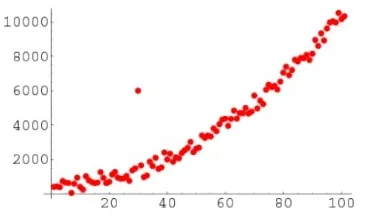

In [26]:
def exclui_outliers(DataFrame, col_name):
  intervalo = 2.7*DataFrame[col_name].std()
  media = DataFrame[col_name].mean()
  DataFrame.loc[df[col_name] < (media - intervalo), col_name] = np.nan
  DataFrame.loc[df[col_name] > (media + intervalo), col_name] = np.nan

  numerical_cols = ['song_duration_ms', 'acousticness', 'danceability',
                  'energy', 'instrumentalness', 'liveness',
                  'loudness', 'speechiness', 'tempo','audio_valence']
for col in numerical_cols:
  exclui_outliers(df, col)

In [24]:
df.head(15)

,song_name,song_popularity,song_duration_ms,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,audio_mode,speechiness,tempo,time_signature,audio_valence
1757,Party In The U.S.A.,NaN,NaN,0.51900,0.360,NaN,NaN,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN
7574,I Love It (& Lil Pump),99,127946.0,0.01140,0.901,0.522,0.000000,2.0,0.2590,-8.304,1,NaN,104.053,4,0.329
17588,"Taki Taki (with Selena Gomez, Ozuna & Cardi B)",98,212500.0,0.15300,0.841,0.798,0.000003,1.0,0.0618,-4.206,0,0.2290,95.948,4,0.591
17394,Promises (with Sam Smith),98,213309.0,0.01190,0.781,0.768,0.000005,11.0,0.3250,-5.991,1,0.0394,123.070,4,0.486
12665,Eastside (with Halsey & Khalid),98,173799.0,0.55500,0.560,0.680,0.000000,6.0,0.1160,-7.648,0,NaN,89.391,4,0.319
17618,In My Feelings,98,217925.0,0.05890,0.835,0.626,0.000060,1.0,0.3960,-5.833,1,0.1250,91.030,4,0.350
8686,SICKO MODE,97,312820.0,0.00513,0.834,0.730,0.000000,8.0,0.1240,-3.714,1,0.2220,155.008,4,0.446
8905,Falling Down,97,196400.0,0.01750,0.669,0.574,0.002940,4.0,0.1460,-6.442,0,0.0286,120.013,4,0.273
7576,In My Mind,97,184560.0,0.17600,0.694,0.770,0.000011,6.0,0.1180,-5.335,1,0.1490,125.905,4,0.163
7581,Lucid Dreams,97,239835.0,0.34900,0.511,0.566,0.000000,6.0,0.3400,-7.230,0,0.2000,83.903,4,0.218


6. **Dados faltantes**
- Por fim, vamos falar sobre dados faltantes ou nulos. Em algumas situações, podemos ter muitas informações incompletas no df, ou pode ser necessário substituir valores errados por NaN. Essas informações faltantes podem prejudicar a análise e outras etapas que dependem dela e do pré-processamento, portanto, precisamos removê-los ou substituir esses valores por outros.

- Uma opçãod é substituir esses dados pela média da coluna, entretanto, às vezes, a média pode ter sido afetada pelos valores destoantes da coluna, então podemos substituir também pela moda ou mediana. Podemos fazer isso com a função .fillna que preenche todos os campos com dados ausentes. Vamos criar alguns loops como exemplo.

- O primeiro passa por algumas colunas e substitui os valores faltantes pela moda:

In [28]:
for column in ['acousticness', 'liveness', 'speechiness']:
    df[column].fillna(df[column].mode()[0], inplace=True)

/tmp/ipython-input-3425059838.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mode()[0], inplace=True)


In [33]:
df.liveness

,liveness
1757,0.1080
7574,0.2590
17588,0.0618
17394,0.3250
12665,0.1160
...,...
11278,0.1130
12923,0.0530
11282,0.1080
12905,0.3390


Agora, substituindo outros valores pela maediana.

In [34]:
for column in ['song_duration_ms',  'danceability', 'energy',
                'loudness', 'audio_valence']:
    df[column].fillna(df[column].mean(), inplace=True)

/tmp/ipython-input-3203962072.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mean(), inplace=True)


In [35]:
df.head(20)

,song_name,song_popularity,song_duration_ms,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,audio_mode,speechiness,tempo,time_signature,audio_valence
1757,Party In The U.S.A.,NaN,212931.472119,0.51900,0.360,0.647337,NaN,NaN,0.1080,0.000,NaN,0.0310,NaN,NaN,0.527024
7574,I Love It (& Lil Pump),99,127946.000000,0.01140,0.901,0.522000,0.000000,2.0,0.2590,-8.304,1,0.0310,104.053,4,0.329000
17588,"Taki Taki (with Selena Gomez, Ozuna & Cardi B)",98,212500.000000,0.15300,0.841,0.798000,0.000003,1.0,0.0618,-4.206,0,0.2290,95.948,4,0.591000
17394,Promises (with Sam Smith),98,213309.000000,0.01190,0.781,0.768000,0.000005,11.0,0.3250,-5.991,1,0.0394,123.070,4,0.486000
12665,Eastside (with Halsey & Khalid),98,173799.000000,0.55500,0.560,0.680000,0.000000,6.0,0.1160,-7.648,0,0.0310,89.391,4,0.319000
17618,In My Feelings,98,217925.000000,0.05890,0.835,0.626000,0.000060,1.0,0.1080,-5.833,1,0.1250,91.030,4,0.350000
8686,SICKO MODE,97,312820.000000,0.00513,0.834,0.730000,0.000000,8.0,0.1240,-3.714,1,0.2220,155.008,4,0.446000
8905,Falling Down,97,196400.000000,0.01750,0.669,0.574000,0.002940,4.0,0.1460,-6.442,0,0.0286,120.013,4,0.273000
7576,In My Mind,97,184560.000000,0.17600,0.694,0.770000,0.000011,6.0,0.1180,-5.335,1,0.1490,125.905,4,0.163000
7581,Lucid Dreams,97,239835.000000,0.34900,0.511,0.566000,0.000000,6.0,0.3400,-7.230,0,0.2000,83.903,4,0.218000
